# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [3]:
!pip install sqlalchemy

In [4]:
!pip install psycopg2

In [5]:
!pip install psycopg2-binary

In [6]:
import pandas as pd
from sqlalchemy import create_engine

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from phik import phik_matrix

In [8]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [9]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [10]:
engine = create_engine(connection_string)

In [11]:
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
-- Напишите ваш запрос ниже
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM p.created_dt_msk - LAG(p.created_dt_msk) OVER (
        PARTITION BY p.user_id
        ORDER BY p.created_dt_msk
    ))::int AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e ON p.event_id = e.event_id
INNER JOIN afisha.city c ON e.city_id = c.city_id
INNER JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id
'''

In [12]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [14]:
df.head(20)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

**Вывод:** Данные выгружены в полном объеме, за исключением days_since_prev, где обнаружены пропуски. Возможно это ожидаемые пропуски, так как по описанию они соответствуют пользователям с одной покупкой, для которых невозможно рассчитать количество дней с предыдущего заказа. Дальше нужно будет посчитать их долю и принять решение о том, как с ними поступить.

Целочисленные столбцы order_id, tickets_count и event_id можно привести к int32 или int16 для оптимизации. days_since_prev тоже можно было бы привести к целочисленному типу, но в них обнаружены пропуски. Категориальные столбцы device_type_canonical, currency_code, event_name, event_type_main, service_name, region_name и city_name можно привести к типу category.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [18]:
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [19]:
tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [20]:
#Преобразуем формат для даты, чтобы в дальнецшем было удобнее работать
tenge_df['data'] = pd.to_datetime(tenge_df['data'])
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [21]:
# Объединяем по дате: в основном датафрейме — order_dt, в tenge_df — data
df = df.merge(tenge_df[['data', 'curs']], left_on='order_dt', right_on='data', how='left')

In [22]:
# Создаём столбец revenue_rub
df['revenue_rub'] = np.where(df['currency_code'] == 'RUB', df['revenue'], df['revenue'] * df['curs'] / 100)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [25]:
# Абсолютное количество пропусков
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
data                         0
curs                         0
revenue_rub                  0
dtype: int64

In [26]:
df.isna().mean()

user_id                  0.000000
device_type_canonical    0.000000
order_id                 0.000000
order_dt                 0.000000
order_ts                 0.000000
currency_code            0.000000
revenue                  0.000000
tickets_count            0.000000
days_since_prev          0.075472
event_id                 0.000000
event_name               0.000000
event_type_main          0.000000
service_name             0.000000
region_name              0.000000
city_name                0.000000
data                     0.000000
curs                     0.000000
revenue_rub              0.000000
dtype: float64

In [27]:
#7,5% пропусков присутствует в базе
#Сохраним количество наблюдений в исходной версии базы
len_df = df.shape[0]

In [28]:
#Поменяем типы данных
df['days_since_prev'] = df['days_since_prev'].astype('Int64')

df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

for col in ['device_type_canonical', 'currency_code', 'event_type_main',
            'service_name', 'region_name', 'city_name']:
    df[col] = df[col].astype('category')

In [29]:
df.dtypes

user_id                          object
device_type_canonical          category
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                  category
revenue                         float64
tickets_count                      int8
days_since_prev                   Int64
event_id                          int64
event_name                       object
event_type_main                category
service_name                   category
region_name                    category
city_name                      category
data                     datetime64[ns]
curs                            float64
revenue_rub                     float64
dtype: object

In [30]:
df['currency_code'].value_counts()

currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

In [31]:
df['device_type_canonical'].value_counts()

device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

In [32]:
df['event_type_main'].value_counts()

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64

In [33]:
df['region_name'].value_counts().head(10)

region_name
Каменевский регион         91058
Североярская область       44049
Широковская область        16457
Медовская область          13901
Озернинский край           10476
Светополянский округ        7607
Малиновоярский округ        6618
Речиновская область         6293
Солнечноземская область     6288
Яблоневская область         6181
Name: count, dtype: int64

In [34]:
df.duplicated().sum()

0

In [35]:
df.duplicated(subset=['order_id', 'event_id']).sum()

0

In [36]:
for col in ['revenue_rub', 'tickets_count']:
    print(df[col].describe())
    print()

count    290611.000000
mean        120.302994
std         238.469900
min         -18.190936
25%          22.566535
50%          68.076833
75%         155.520110
max       15520.734397
Name: revenue_rub, dtype: float64

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64



**Вывод:** в данных есть асимметрия, и странно, что значение выручки может быть отрицательным. В дальнейшем было решено его отфильтровать и оставить только неотрицательные значения

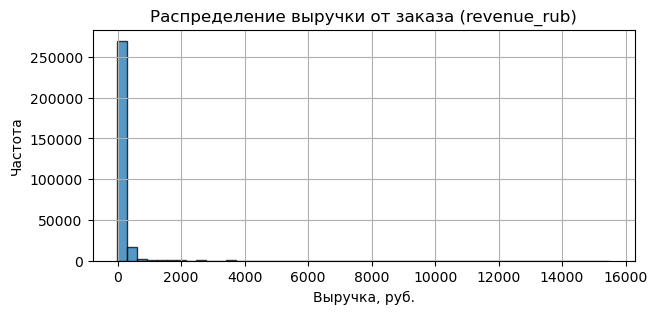

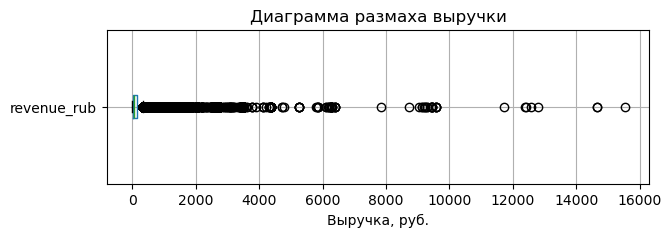

In [38]:
plt.figure(figsize=(7, 3))
df['revenue_rub'].plot(kind='hist', bins=50, edgecolor='black', alpha=0.75)
plt.title('Распределение выручки от заказа (revenue_rub)')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')
plt.grid()
plt.show()

plt.figure(figsize=(7, 2))
df.boxplot(column='revenue_rub', vert=False)
plt.title('Диаграмма размаха выручки')
plt.xlabel('Выручка, руб.')
plt.show()

In [39]:
#Для фильтрации
q99 = df['revenue_rub'].quantile(0.99)
print(f'99-й перцентиль revenue_rub = {q99:.2f} руб.')
# Фильтруем
df = df[df['revenue_rub'] >= 0]

df = df[df['revenue_rub'] <= q99]

len_new_df = df.shape[0]

print(f'Вывод: Удалено {len_df - len_new_df} наблюдений ({(len_df - len_new_df) / len_df * 100:.2f}% от исходной базы)')

99-й перцентиль revenue_rub = 761.78 руб.
Вывод: Удалено 3288 наблюдений (1.13% от исходной базы)


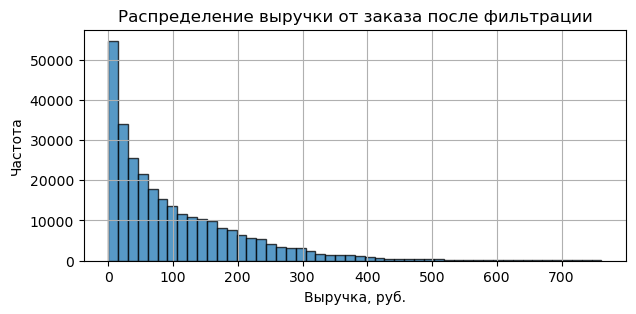

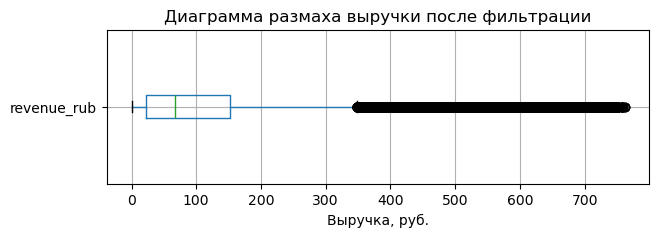

In [40]:
plt.figure(figsize=(7, 3))
df['revenue_rub'].plot(kind='hist', bins=50, edgecolor='black', alpha=0.75)
plt.title('Распределение выручки от заказа после фильтрации')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')
plt.grid()
plt.show()

plt.figure(figsize=(7, 2))
df.boxplot(column='revenue_rub', vert=False)
plt.title('Диаграмма размаха выручки после фильтрации')
plt.xlabel('Выручка, руб.')
plt.show()

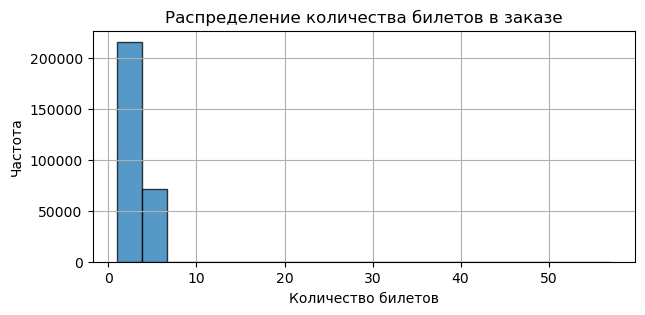

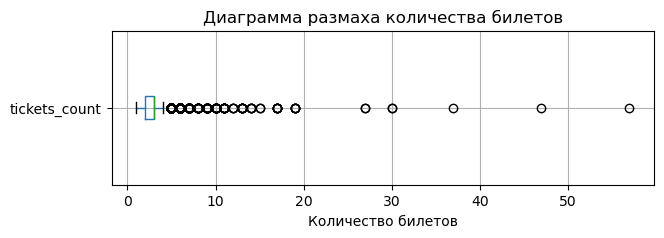

In [41]:
plt.figure(figsize=(7, 3))
df['tickets_count'].plot(kind='hist', bins=20, edgecolor='black', alpha=0.75)
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
plt.grid()
plt.show()

plt.figure(figsize=(7, 2))
df.boxplot(column='tickets_count', vert=False)
plt.title('Диаграмма размаха количества билетов')
plt.xlabel('Количество билетов')
plt.show()

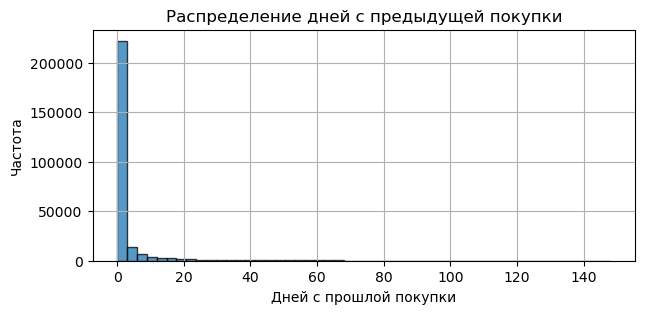

In [42]:
df['days_since_prev'].describe()

plt.figure(figsize=(7, 3))
df['days_since_prev'].plot(kind='hist', bins=50, edgecolor='black', alpha=0.75)
plt.title('Распределение дней с предыдущей покупки')
plt.xlabel('Дней с прошлой покупки')
plt.ylabel('Частота')
plt.grid()
plt.show()

**Вывод:** На первом этапе был создан новый столбец с выручкой, выраженной в рублях revenue_rub. Затем была проведена проверка пропущенных значений, пропуски были обнаружены только в столбце days_since_prev, что составляет примерно 7.5% от всех данных. Поскольку появление пропусков логично, из-за того что не у всех ползователей есть несколько заказов, было решено их созранить в исходном виде.

На следующем шаге были преобразованы типы данных: столбец days_since_prev переведён в Int64; столбец tickets_count приведен к более оптимальному типу по размеру; категориальные признаки device_type_canonical, currency_code, event_type_main, service_name, region_name и city_name переведены в тип category.

Далее были изучены значения в столбцах, обозначений пропуски или отсутствия информации обнаружено не было, поэтому очистка не потребовалась. Также была проведена проверка дубликатов: полных дубликатов строк в данных нет. На этапе анализа численных данных проверены распределения ключевых признаков: выручка revenue_rub имеет сильно скошенное вправо распределение с длинным хвостом крупных заказов, где среднее значение заметно превышает медиану; количество билетов tickets_count в большинстве заказов равно двум, также образовался правый хвост; дни с предыдущей покупки days_since_prev также распределены с правосторонней асимметрией. 

Для снижения влияния аномально крупных заказов на дальнейший анализ была проведена фильтрация выбросов в столбце revenue_rub по 99-му перцентилю, а также удалены отрицательные значения. В итоге была сократилась на 1.13% от исходного объема.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [45]:
# Сортируем по времени создания заказа
df = df.sort_values(by='order_ts').reset_index(drop=True)

df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,curs,revenue_rub
0,fd4d47438ebb946,mobile,7565637,2024-06-01,2024-06-01 00:00:42,rub,1083.15,4,0,131671,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Прачечная,Каменевский регион,Глиногорск,2024-06-01,20.2773,219.633575
1,fd4d47438ebb946,mobile,7565521,2024-06-01,2024-06-01 00:01:30,rub,812.36,3,0,131671,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Прачечная,Каменевский регион,Глиногорск,2024-06-01,20.2773,164.724674
2,57ef0a1905ac488,mobile,6670842,2024-06-01,2024-06-01 00:01:58,rub,2091.31,4,<NA>,375861,ba89f19f-e73c-4d74-ab35-b9c023bb4de6,театр,Билеты в руки,Лесодальний край,Родниковец,2024-06-01,20.2773,424.061203
3,fd4d47438ebb946,mobile,7565550,2024-06-01,2024-06-01 00:03:13,rub,812.36,3,0,131671,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Прачечная,Каменевский регион,Глиногорск,2024-06-01,20.2773,164.724674
4,e73089d7d016cd8,mobile,5502055,2024-06-01,2024-06-01 00:03:34,rub,181.39,2,0,211846,20165b73-7202-48df-a5e3-fd8cd1a70554,театр,Прачечная,Широковская область,Радужнополье,2024-06-01,20.2773,36.780994


In [46]:
# Строим профиль пользователя
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    orders_count=('order_id', 'count'),
    mean_revenue=('revenue_rub', 'mean'),
    mean_tickets=('tickets_count', 'mean'),
    mean_days_between=('days_since_prev', 'mean')
).reset_index()

user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,orders_count,mean_revenue,mean_tickets,mean_days_between
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,284.560166,4.000000,<NA>
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,150.184085,3.000000,75.0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,152.006479,2.666667,51.0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,172.304226,4.000000,<NA>
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,12.007135,1.500000,16.0


In [47]:
user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype(int)

user_profile['is_five'] = (user_profile['orders_count'] >= 5).astype(int)

user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,orders_count,mean_revenue,mean_tickets,mean_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,284.560166,4.000000,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,150.184085,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,152.006479,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,172.304226,4.000000,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,12.007135,1.500000,16.0,1,0


In [48]:
rows_before = user_profile.shape[0]

In [49]:
#Проверка распределения признаков
print(user_profile[['is_two', 'is_five']].mean())
#Посмотрим на показатели
user_profile[['orders_count', 'mean_revenue', 'mean_tickets', 'mean_days_between']].describe()

is_two     0.617535
is_five    0.290791
dtype: float64


,orders_count,mean_revenue,mean_tickets,mean_days_between
count,21751.000000,21751.000000,21751.000000,13476.0
mean,13.209646,110.195718,2.749224,15.962117
std,122.044008,95.189014,0.921398,22.414921
min,1.000000,0.000000,1.000000,0.0
25%,1.000000,42.493277,2.000000,1.0
50%,2.000000,91.247478,2.750000,8.125
75%,5.000000,150.141240,3.111111,20.6
max,10194.000000,750.022856,11.000000,148.0


**Вывод:** пользователей с 2 и более заказами в два раза больше, чем пользователей с 5 и более заказами. По описательным статистикам видно, что orders_count и mean_revenue имеют выбросы, так как максимальные значения сильно отличны от типичных, а мода и медиана расположены далеко друг от друга.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [52]:
total_users = user_profile['user_id'].nunique()
print(f'Общее число пользователей: {total_users} человек')

mean_revenue_all = df['revenue_rub'].mean() #тут показалось, что правильнее считать по df
print(f'Средняя выручка с одного заказа: {mean_revenue_all:.2f} руб.')

share_two = user_profile['is_two'].mean()
print(f'Доля пользователей с 2 и более заказами: {share_two:.2%}')

share_five = user_profile['is_five'].mean()
print(f'Доля пользователей с 5 и более заказами: {share_five:.2%}')

Общее число пользователей: 21751 человек
Средняя выручка с одного заказа: 103.29 руб.
Доля пользователей с 2 и более заказами: 61.75%
Доля пользователей с 5 и более заказами: 29.08%


In [53]:
# Статистика по числу заказов
user_profile['orders_count'].describe()

count    21751.000000
mean        13.209646
std        122.044008
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10194.000000
Name: orders_count, dtype: float64

In [54]:
# Статистика по среднему числу билетов
user_profile['mean_tickets'].describe()

count    21751.000000
mean         2.749224
std          0.921398
min          1.000000
25%          2.000000
50%          2.750000
75%          3.111111
max         11.000000
Name: mean_tickets, dtype: float64

In [55]:
# Статистика по среднему числу дней между покупками
user_profile['mean_days_between'].describe()

count      13476.0
mean     15.962117
std      22.414921
min            0.0
25%            1.0
50%          8.125
75%           20.6
max          148.0
Name: mean_days_between, dtype: Float64

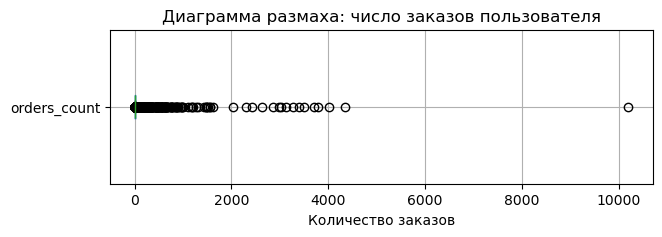

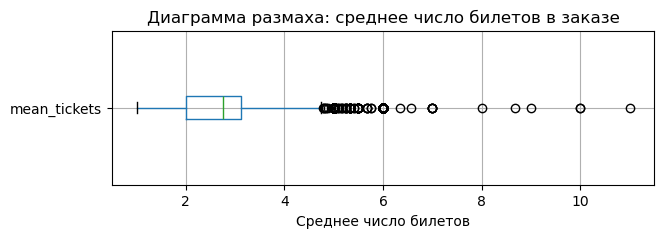

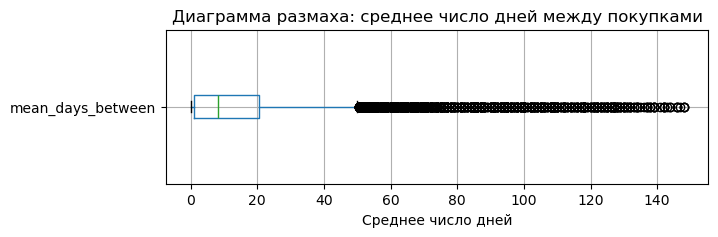

In [56]:
plt.figure(figsize=(7, 2))
user_profile.boxplot(column='orders_count', vert=False)
plt.title('Диаграмма размаха: число заказов пользователя')
plt.xlabel('Количество заказов')
plt.show()

plt.figure(figsize=(7, 2))
user_profile.boxplot(column='mean_tickets', vert=False)
plt.title('Диаграмма размаха: среднее число билетов в заказе')
plt.xlabel('Среднее число билетов')
plt.show()

plt.figure(figsize=(7, 2))
user_profile.boxplot(column='mean_days_between', vert=False)
plt.title('Диаграмма размаха: среднее число дней между покупками')
plt.xlabel('Среднее число дней')
plt.show()

In [57]:
# Границы по 95
q95_orders = user_profile['orders_count'].quantile(0.95)
q95_tickets = user_profile['mean_tickets'].quantile(0.95)

user_profile_clean = user_profile[(user_profile['orders_count'] <= q95_orders) & (user_profile['mean_tickets'] <= q95_tickets)]

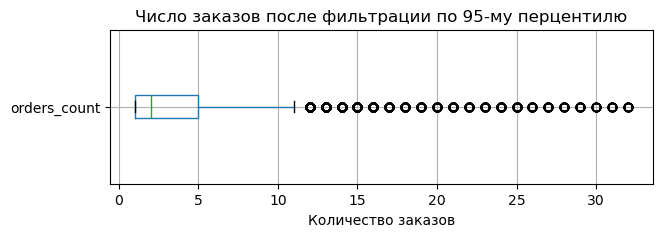

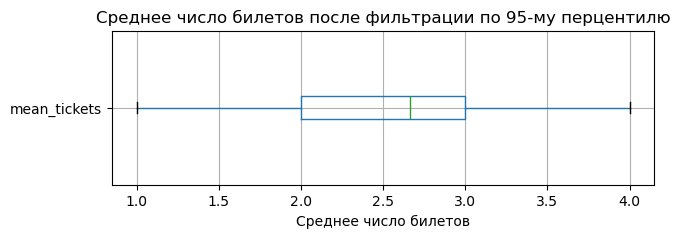

In [58]:
# Диаграмма размаха после фильтрации
plt.figure(figsize=(7, 2))
user_profile_clean.boxplot(column='orders_count', vert=False)
plt.title('Число заказов после фильтрации по 95-му перцентилю')
plt.xlabel('Количество заказов')
plt.show()

plt.figure(figsize=(7, 2))
user_profile_clean.boxplot(column='mean_tickets', vert=False)
plt.title('Среднее число билетов после фильтрации по 95-му перцентилю')
plt.xlabel('Среднее число билетов')
plt.show()

In [59]:
print(f'Доля пользователей с 2 и более заказами:{user_profile_clean["is_two"].mean():.2%}')
print(f'Доля пользователей с 5иболее заказами:{user_profile_clean["is_five"].mean():.2%}')
#Проверила не изменилось ли соотношение, доли изменились совсем чуть-чутьь

Доля пользователей с 2 и более заказами:60.53%
Доля пользователей с 5иболее заказами:26.21%


In [60]:
rows_after = user_profile_clean.shape[0]

print(f'Уделено {rows_before - rows_after} (что составило {(rows_before - rows_after) / rows_before:.2%})')

Уделено 2070 (что составило 9.52%)


In [61]:
user_profile[['orders_count', 'mean_tickets']].describe().round(2)

,orders_count,mean_tickets
count,21751.00,21751.00
mean,13.21,2.75
std,122.04,0.92
min,1.00,1.00
25%,1.00,2.00
50%,2.00,2.75
75%,5.00,3.11
max,10194.00,11.00


In [62]:
user_profile_clean[['orders_count', 'mean_tickets']].describe().round(2)

,orders_count,mean_tickets
count,19681.00,19681.00
mean,4.18,2.63
std,5.30,0.80
min,1.00,1.00
25%,1.00,2.00
50%,2.00,2.67
75%,5.00,3.00
max,32.00,4.00


**Вывод:** Мы расчитали ключевые показатели: общее число пользователей, средняя выручка с одного заказа, а также доли пользователей, совершивших 2 и более и 5 и более заказов. Таким образом, выборка содержит 21 751 пользователя, средняя выручка с одного заказа составляет 103.29 руб.. Доля пользователей с 2 и более заказами — 61.75%, с 5 и более заказами — 29.08%, то есть почти две трети клиентов возвращаются повторно, а каждый третий является активным покупателем.

Анализ показал, что данных достаточно по объёму, но распределения числа заказов и среднего количества билетов имели большое число выбросов. Чтобы снизить влияние этих нетипичных значений на дальнейший анализ, была проведена фильтрация по 95-му перцентилю в обоих столбцах. В результате данные сократились на 9,52%. Соотношение пользователей с 2 и более заказами составило 60.53%, а с 5 и более - 25.21%.

Показатель mean_days_between не фильтровался, так как большие значения скорее показывают реальное поведение клиентов, которые вернулись спустя большое количество времени.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


                  Пользователей   Доля
first_event_type                      
концерты                   9453  0.435
другое                     5521  0.254
театр                      4334  0.199
стендап                    1126  0.052
спорт                       807  0.037
выставки                    415  0.019
ёлки                         95  0.004



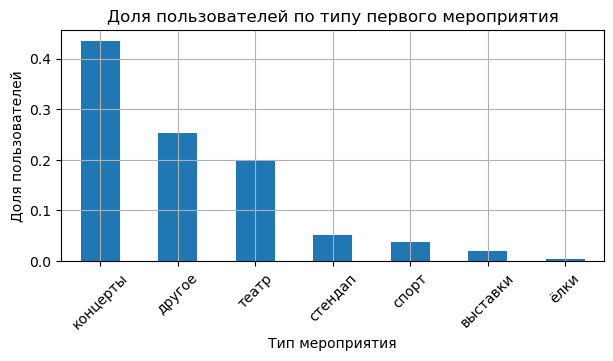

In [66]:
counts = user_profile['first_event_type'].value_counts()
shares = user_profile['first_event_type'].value_counts(normalize=True)

dist_event = pd.DataFrame({
    'Пользователей': counts,
    'Доля': shares.round(3)
})
print(dist_event)
print()

plt.figure(figsize=(7, 3))
shares.plot(kind='bar', rot=45, legend=False,
            title='Доля пользователей по типу первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля пользователей')
plt.grid()
plt.show()

              Пользователей   Доля
first_device                      
mobile                18037  0.829
desktop                3714  0.171



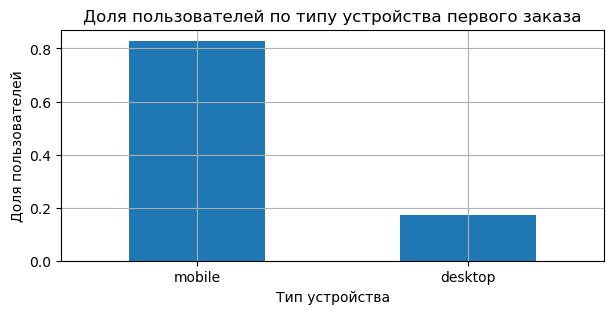

In [67]:
counts = user_profile['first_device'].value_counts()
shares = user_profile['first_device'].value_counts(normalize=True)

dist_device = pd.DataFrame({
    'Пользователей': counts,
    'Доля': shares.round(3)
})
print(dist_device)
print()

plt.figure(figsize=(7, 3))
shares.plot(kind='bar', rot=0, legend=False,
            title='Доля пользователей по типу устройства первого заказа')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.grid()
plt.show()

                          Пользователей   Доля
first_region                                  
Каменевский регион                 7228  0.332
Североярская область               3824  0.176
Широковская область                1251  0.058
Озернинский край                    685  0.031
Малиновоярский округ                545  0.025
...                                 ...    ...
Залесский край                        2  0.000
Тихогорская область                   2  0.000
Верхозёрский край                     1  0.000
Сосноводолинская область              1  0.000
Яснопольский округ                    1  0.000

[81 rows x 2 columns]



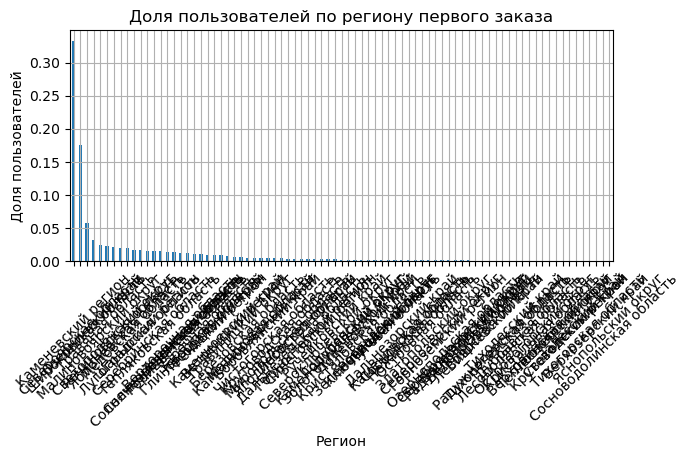

In [68]:
counts = user_profile['first_region'].value_counts()
shares = user_profile['first_region'].value_counts(normalize=True)

dist_region = pd.DataFrame({
    'Пользователей': counts,
    'Доля': shares.round(3)
})
print(dist_region)
print()

plt.figure(figsize=(7, 3))
shares.plot(kind='bar', rot=45, legend=False,
            title='Доля пользователей по региону первого заказа')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей')
plt.grid()
plt.show()

                        Пользователей   Доля
first_service                               
Билеты без проблем               5216  0.240
Лови билет!                      2874  0.132
Мой билет                        2777  0.128
Билеты в руки                    2599  0.119
Облачко                          2213  0.102
Весь в билетах                   1326  0.061
Лучшие билеты                    1193  0.055
Прачечная                         598  0.027
Край билетов                      463  0.021
Дом культуры                      360  0.017
Яблоко                            321  0.015
Тебе билет!                       313  0.014
Городской дом культуры            221  0.010
Мир касс                          211  0.010
За билетом!                       206  0.009
Show_ticket                       172  0.008
Быстробилет                       164  0.008
Выступления.ру                     97  0.004
Восьмёрка                          88  0.004
Быстрый кассир                     59  0.003
Росбилет  

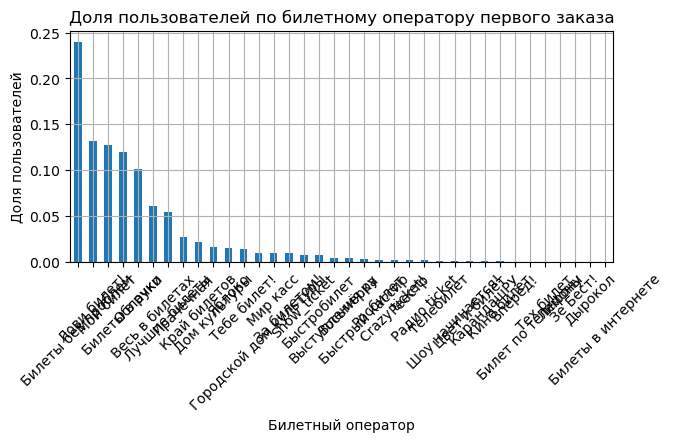

In [69]:
counts = user_profile['first_service'].value_counts()
shares = user_profile['first_service'].value_counts(normalize=True)

dist_service = pd.DataFrame({
    'Пользователей': counts,
    'Доля': shares.round(3)
})
print(dist_service)
print()

plt.figure(figsize=(7, 3))
shares.plot(kind='bar', rot=45, legend=False,
            title='Доля пользователей по билетному оператору первого заказа')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля пользователей')
plt.grid()
plt.show()

**Вывод:** Пользователи распределены неравномерно по сегментам. По типу первого мероприятия точкой входа являются концерты, на которые приходится 43.5% пользователей; следущими по популярности являлись «другое» (25.4%) и «театр» (19.9%), а спортивные события, выставки и ёлки вместе набрали менее 6%.

По типу устройства 82.9% пользователей совершают первую покупку с мобильного, и лишь 17.1% с десктопа. Следовательно, смартфон оказывается главным каналом первого знакомства с сервисом.

По региону распределение треть пользователей (33.2%) приходит из Каменевского региона и ещё 17.6% — из Североярской области, что составляет в совокупности больше половины всех новых клиентов.

По билетному оператору лидируют «Билеты без проблем» (24%), «Лови билет!» (13.2%), «Мой билет» (12.8%), «Билеты в руки» (11.9%) и «Облачко» (10.2%), которые вместе охватили около 72% пользователей. Остальные операторы имели доли менее 1%.

Таким образом, типичный новый пользователь Яндекс Афиши приходит с мобильного телефона, на концерт, из Каменевского региона или Североярской области и через одного из пяти крупнейших билетных операторов. Данные категории формируют базовый портрет клиента.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Средняя доля вернувшихся по выборке: 0.618
                  users  return_share
first_event_type                     
выставки            415         0.643
другое             5521         0.602
концерты           9453         0.621
спорт               807         0.565
стендап            1126         0.614
театр              4334         0.641
ёлки                 95         0.547


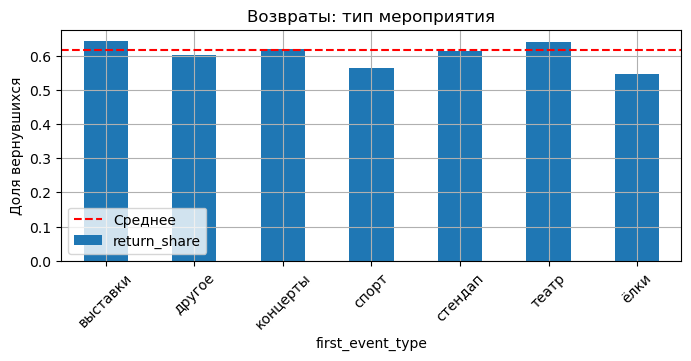

In [73]:
mean_share = user_profile['is_two'].mean()

print(f'Средняя доля вернувшихся по выборке: {mean_share:.3f}')


grouped = user_profile.groupby('first_event_type', observed=True).agg( users=('user_id', 'count'),
    return_share=('is_two', 'mean'))
print(grouped.round(3))

plt.figure(figsize=(8, 3))
grouped['return_share'].plot(kind='bar', rot=45,
                             title='Возвраты: тип мероприятия')
plt.axhline(mean_share, color='red', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся')
plt.legend()
plt.grid()
plt.show()

              users  return_share
first_device                     
desktop        3714         0.640
mobile        18037         0.613


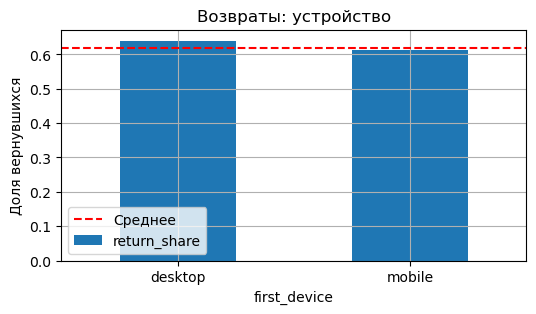

In [74]:
grouped = user_profile.groupby('first_device', observed=True).agg( users=('user_id', 'count'),
    return_share=('is_two', 'mean'))
print(grouped.round(3))

plt.figure(figsize=(6, 3))
grouped['return_share'].plot(kind='bar', rot=0,
                             title='Возвраты: устройство')
plt.axhline(mean_share, color='red', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся')
plt.legend()
plt.grid()
plt.show()

                      users  return_share
first_region                             
Каменевский регион     7228         0.630
Североярская область   3824         0.644
Широковская область    1251         0.651
Озернинский край        685         0.556
Малиновоярский округ    545         0.571
Травяная область        494         0.619
Светополянский округ    475         0.669
Речиновская область     447         0.644
Яблоневская область     419         0.599
Медовская область       379         0.599


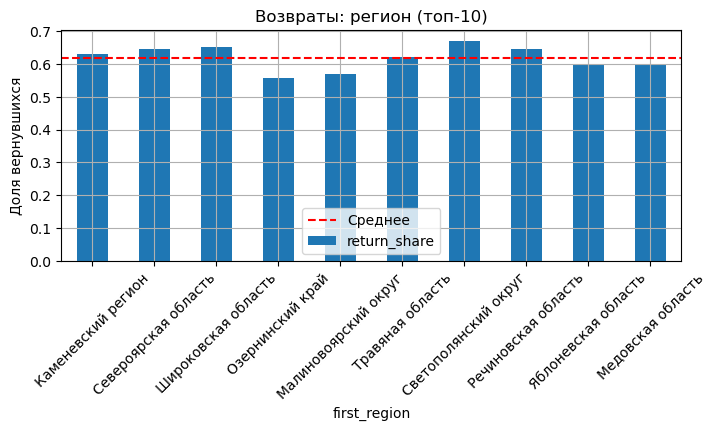

In [75]:
grouped = user_profile.groupby('first_region', observed=True).agg( users=('user_id', 'count'),
    return_share=('is_two', 'mean')).sort_values('users', ascending=False).head(10)

print(grouped.round(3))

plt.figure(figsize=(8, 3))
grouped['return_share'].plot(kind='bar', rot=45,
                             title='Возвраты: регион (топ-10)')
plt.axhline(mean_share, color='red', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся')
plt.legend()
plt.grid()
plt.show()

                    users  return_share
first_service                          
Билеты без проблем   5216         0.610
Лови билет!          2874         0.618
Мой билет            2777         0.596
Билеты в руки        2599         0.634
Облачко              2213         0.619
Весь в билетах       1326         0.637
Лучшие билеты        1193         0.616
Прачечная             598         0.632
Край билетов          463         0.657
Дом культуры          360         0.653


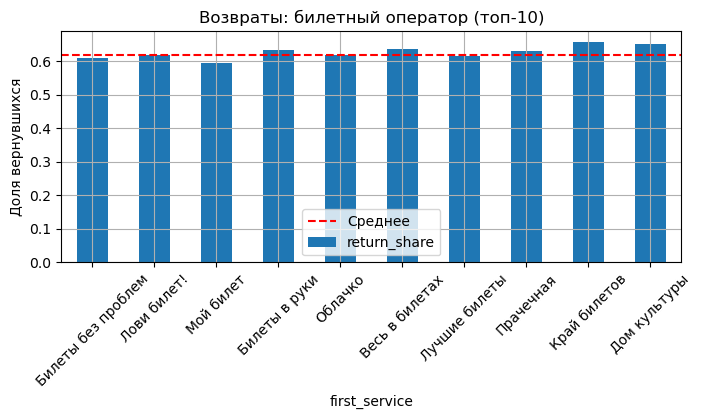

In [76]:
grouped = user_profile.groupby('first_service', observed=True).agg(users=('user_id', 'count'),
    return_share=('is_two', 'mean')).sort_values('users', ascending=False).head(10)

print(grouped.round(3))

plt.figure(figsize=(8, 3))
grouped['return_share'].plot(kind='bar', rot=45,
                             title='Возвраты: билетный оператор (топ-10)')
plt.axhline(mean_share, color='red', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся')
plt.legend()
plt.grid()
plt.show()

**Вывод:** Средняя доля вернувшихся пользователей по всей выборке составляет 61.8%.

По типу первого мероприятия лидируют выставки (64.3%) и театр (64.1%), их значения превысили среднее. Концерты (62.1%), которые являлись самым массовым сегментом, рказались чуть выше среднего. Спорт (56.5%) и ёлки (54.7%) оказались ниже.

По типу устройства desktop (64.0%) удерживает чуть лучше, чем mobile (61.3%).

По регионам в топ-10 выше среднего удерживают Светополянский округ (66.9%), Широковская область (65.1%), Североярская область (64.4%) и Речиновская область (64.4%).

По билетным операторам практически все из топ-10 держатся в диапазоне 0.60–0.66. Лучше среднего удерживают Край билетов (65.7%), Дом культуры (65.3%), Весь в билетах (63.7%) и Билеты в руки (63.4%).

Таким образом, успешные точки входа представляют театр, выставки, desktop, Светополянский и Широковский регионы, а также операторы «Край билетов» и «Дом культуры», в которых доля возврата превышает среднюю по выборке. Спортивные события, ёлки и Озернинский край удерживают хуже среднего.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [79]:
grouped = user_profile[
    user_profile['first_event_type'].isin(['спорт', 'концерты'])].groupby('first_event_type', observed=True).agg(
    users=('user_id', 'count'),
    return_share=('is_two', 'mean'))

print(grouped.round(3))

                  users  return_share
first_event_type                     
концерты           9453         0.621
спорт               807         0.565


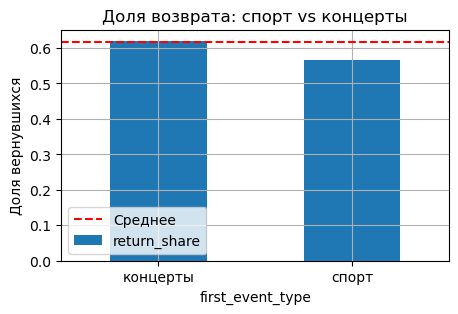

In [80]:
plt.figure(figsize=(5, 3))
grouped['return_share'].plot(kind='bar', rot=0,
                             title='Доля возврата: спорт vs концерты')
plt.axhline(mean_share, color='red', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся')
plt.legend()
plt.grid()
plt.show()

In [81]:
region_stats = user_profile.groupby('first_region', observed=True).agg(users=('user_id', 'count'), return_share=('is_two', 'mean'))
#Так как данные скошены, лучше использовать медиану
median_users = region_stats['users'].median()
print(f'Медиана числа пользователей по регионам: {median_users:.0f}')

top_regions = region_stats[region_stats['users'] > median_users]
low_regions = region_stats[region_stats['users'] <= median_users]

print(f'Активных регионов: {len(top_regions)}')
print(f'Менее активных:    {len(low_regions)}')

print(f'Средняя доля возврата в активных:    {top_regions["return_share"].mean():.3f}')
print(f'Средняя доля возврата в менее активных:       {low_regions["return_share"].mean():.3f}')

Медиана числа пользователей по регионам: 54
Активных регионов: 40
Менее активных:    41
Средняя доля возврата в активных:    0.595
Средняя доля возврата в менее активных:       0.527


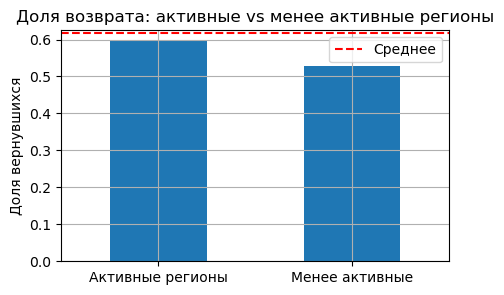

In [82]:
plt.figure(figsize=(5, 3))
pd.Series({'Активные регионы': top_regions['return_share'].mean(), 'Менее активные':   low_regions['return_share'].mean()}).plot(kind='bar', rot=0, title='Доля возврата: активные vs менее активные регионы')
plt.axhline(mean_share, color='red', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся')
plt.legend()
plt.grid()
plt.show()

**Вывод:** Гипотеза 1 не подтвердилась (опровергнута), доля возврата в сегменте «спорт» составляет 56.5%, а в сегменте «концерты» 62.1%. Первый заказ на концерт связан с более высокой вероятностью повторной покупки, чем первый заказ на спортивное мероприятие.
Гипотезу 2 не отклонилась. В активных регионах средняя доля возврата составляет 59.5%, а в менее активных 52.7%.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [85]:
df['avg_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

df[['revenue_rub', 'tickets_count', 'avg_revenue_rub']].head()

,revenue_rub,tickets_count,avg_revenue_rub
0,219.633575,4,54.908394
1,164.724674,3,54.908225
2,424.061203,4,106.015301
3,164.724674,3,54.908225
4,36.780994,2,18.390497


In [86]:
user_avg = df.groupby('user_id')['avg_revenue_rub'].mean().reset_index()
user_avg.columns = ['user_id', 'avg_revenue_rub']

user_avg = user_avg.merge(
    user_profile[['user_id', 'is_two']],
    on='user_id')

user_avg.head()

,user_id,avg_revenue_rub,is_two
0,0002849b70a3ce2,71.140041,0
1,0005ca5e93f2cf4,44.182350,1
2,000898990054619,50.756089,1
3,00096d1f542ab2b,43.076056,0
4,000a55a418c128c,8.317804,1


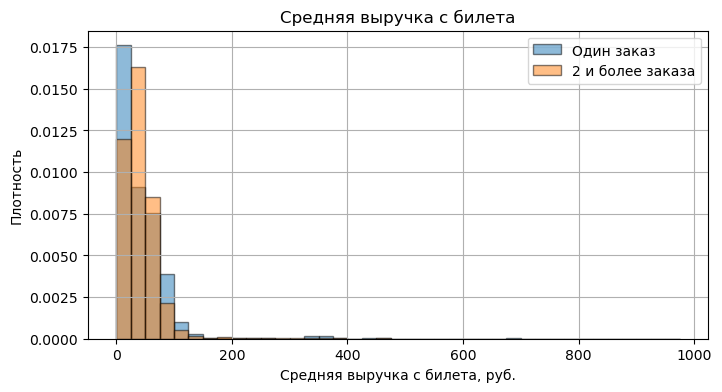

In [87]:
one_order = user_avg[user_avg['is_two'] == 0]['avg_revenue_rub']
returned  = user_avg[user_avg['is_two'] == 1]['avg_revenue_rub']

bins = range(0, 1000, 25)

plt.figure(figsize=(8, 4))
one_order.plot(kind='hist', bins = bins, alpha=0.5, density=True,
               label='Один заказ', edgecolor='black')
returned.plot(kind='hist',  bins = bins, alpha=0.5, density=True,
              label='2 и более заказа', edgecolor='black')

plt.title('Средняя выручка с билета')
plt.xlabel('Средняя выручка с билета, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.grid()
plt.show()

In [88]:
# Смотрим среднее и медиану по каждой группе
print('Средняя выручка по одному заказу:', round(one_order.mean(), 2), 'руб.')
print('Средняя выручка по 2 и более заказам: ', round(returned.mean(), 2), 'руб.')

print('Медианная выручка по одному заказ:', round(one_order.median(), 2), 'руб.')
print('Медианная выручка по 2 и более заказам: ', round(returned.median(), 2), 'руб.')

Средняя выручка по одному заказу: 41.61 руб.
Средняя выручка по 2 и более заказам:  40.89 руб.
Медианная выручка по одному заказ: 31.37 руб.
Медианная выручка по 2 и более заказам:  37.21 руб.


**Вывод:** Средняя выручка у двух групп пользователей оказалась практически одинаковой: среднее значение у пользователей с один заказом составило 41.61 руб., с 2 и более 40.89 руб. Медианные значения различаются больше, у пользовптелей с одним заказом 31.37 руб., с 2 и более 37.21 руб.. Судя по гистограмме, значения обеих групп сосредоточены в схожем диапазоне примерно 0–50 рублей за билет, при более двух заказах пик находит чуть правее. Клиенты с одним заказом чаще покупают дешёвые билеты (медиана 31 руб.), но среди них встречаются редкие дорогие покупки, которые поднимают среднее. Клиенты с 2 и более заказами распределены более равномерно по ценовому диапазону, медиана и среднее близки друг к другу.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [91]:
group_2_4 = user_profile[(user_profile['orders_count'] >= 2) & (user_profile['orders_count'] <= 4)]['mean_revenue']

group_5plus = user_profile[user_profile['orders_count'] >= 5]['mean_revenue']

print(f'2 - 4 заказа: {len(group_2_4)} пользователей')
print(f'5 и более заказов: {len(group_5plus)} пользователей')

2 - 4 заказа: 7107 пользователей
5 и более заказов: 6325 пользователей


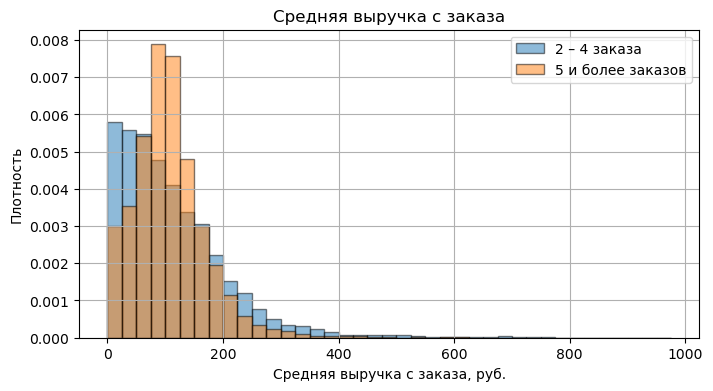

In [92]:
bins = range(0, 1000, 25)

plt.figure(figsize=(8, 4))
group_2_4.plot(kind='hist', bins=bins, alpha=0.5, density=True,
               label='2 – 4 заказа', edgecolor='black')
group_5plus.plot(kind='hist', bins=bins, alpha=0.5, density=True,
                 label='5 и более заказов', edgecolor='black')

plt.title('Средняя выручка с заказа')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.grid()
plt.show()

In [93]:
print('2–4 заказа:')
print(f'  среднее = {group_2_4.mean():.2f} руб.')
print(f'  медиана = {group_2_4.median():.2f} руб.')

print('5 и более заказов:')
print(f'  среднее = {group_5plus.mean():.2f} руб.')
print(f'  медиана = {group_5plus.median():.2f} руб.')

2–4 заказа:
  среднее = 112.16 руб.
  медиана = 91.31 руб.
5 и более заказов:
  среднее = 107.33 руб.
  медиана = 100.42 руб.


**Вывод:** есть небольшие различия. Пользователи, совершившие 5 и болнн заказов, имеют более высокую медианную выручку. Однако по среднему значению в пользователи с 2–4 заказами оказалист выше. При наложении распределений также увидели, что форма у двух групп схожа. У группы с 5 и более заказами пик сдвинут левее.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

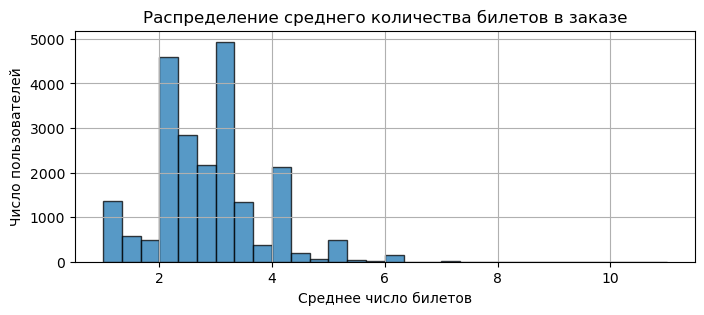

count    21751.00
mean         2.75
std          0.92
min          1.00
25%          2.00
50%          2.75
75%          3.11
max         11.00
Name: mean_tickets, dtype: float64

In [96]:
# Гистограмма распределения
plt.figure(figsize=(8, 3))
user_profile['mean_tickets'].plot(kind='hist', bins=30,
                                  edgecolor='black', alpha=0.75)
plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее число билетов')
plt.ylabel('Число пользователей')
plt.grid()
plt.show()

user_profile['mean_tickets'].describe().round(2)

In [97]:
# Определяем сегмент для каждого пользователя
def ticket_segment(x):
    if x <= 2:
        return '1–2 билета'
    elif x <= 3:
        return '2–3 билета'
    elif x <= 5:
        return '3–5 билетов'
    else:
        return '5 и более билетов'

user_profile['ticket_segment'] = user_profile['mean_tickets'].apply(ticket_segment)

In [98]:
grouped = user_profile.groupby('ticket_segment', observed=True).agg(
    users=('user_id', 'count'),
    return_share=('is_two', 'mean')
)

# Упорядочим сегменты по возрастанию числа билетов
order = ['1–2 билета', '2–3 билета', '3–5 билетов', '5 и более билетов']
grouped = grouped.reindex(order)

print(grouped.round(3))

                   users  return_share
ticket_segment                        
1–2 билета          6166         0.402
2–3 билета          9947         0.749
3–5 билетов         5433         0.632
5 и более билетов    205         0.332


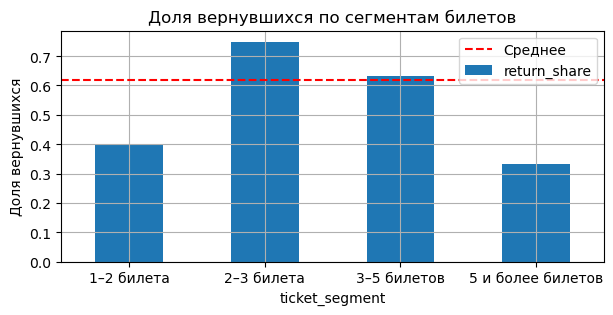

In [99]:
plt.figure(figsize=(7, 3))
grouped['return_share'].plot(kind='bar', rot=0,
                             title='Доля вернувшихся по сегментам билетов')
plt.axhline(mean_share, color='red', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся')
plt.legend()
plt.grid()
plt.show()

**Вывод:** Распределение пользователей по среднему количеству билетов неравномерно. Около половины клиентов приходится на сегмент «2–3 билета», ещё 6166 на «1–2 билета» и 5433 на «3–5 билетов», тогда как сегмент «5 и более билетов» оказался наименьшим по размеру. Аномально высокая доля возврата наблюдается в сегменте «2–3 билета», составила 74.9%, что заметно выше остальных. В то же время аномально низкая в сегменте «5 и более билетов», где всего 33.2%. Чаще всего возвращаются клиенты, покупающие в среднем 2–3 билета, а реже с 1–2 билетами или 5 и более.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [102]:
# День недели из даты первого заказа
user_profile['first_weekday'] = user_profile['first_order_dt'].dt.dayofweek

In [103]:
grouped = user_profile.groupby('first_weekday').agg(
    users=('user_id', 'count'),
    return_share=('is_two', 'mean')
)

print(grouped.round(3))

               users  return_share
first_weekday                     
0               2889         0.632
1               3113         0.617
2               3063         0.622
3               3120         0.600
4               3286         0.601
5               3459         0.641
6               2821         0.608


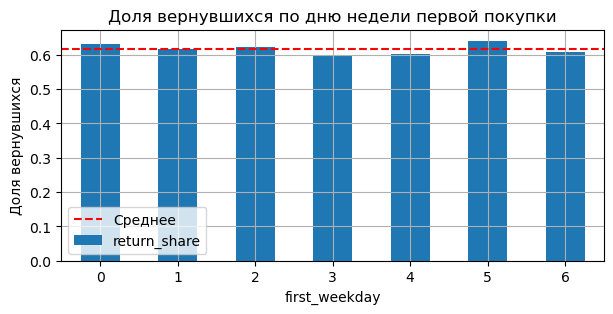

In [104]:
plt.figure(figsize=(7, 3))
grouped['return_share'].plot(kind='bar', rot=0,
                             title='Доля вернувшихся по дню недели первой покупки')
plt.axhline(mean_share, color='red', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся')
plt.legend()
plt.grid()
plt.show()

#не могу сообразить как привести горизонтальнцю ось с понятному виду, чтобы было ясно какие дни недели: пн, вт, ср

**Вывод:** Судя по полученным результатам, доля вернувшихся пости не различается в разные дни покупки день. Число пользователей распределено по дням недели достаточно равномерно. Минимум 60.0% в четверг, а максимум 64.1% в субботу. Все значения держатся около средней доли возврата.  Можно предположить, что день недели первой покупки не является значимым фактором возврата.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [107]:
group_2_4 = user_profile[(user_profile['orders_count'] >= 2) & (user_profile['orders_count'] <= 4)]['mean_days_between']

group_5plus = user_profile[user_profile['orders_count'] >= 5]['mean_days_between']

print(f'2 – 4 заказа: {len(group_2_4)} пользователей')
print(f'5 и более заказов: {len(group_5plus)} пользователей')

2 – 4 заказа: 7107 пользователей
5 и более заказов: 6325 пользователей


In [108]:
print('2 – 4 заказа:')
print(f'  среднее = {group_2_4.mean():.1f} дней')
print(f'  медиана = {group_2_4.median():.1f} дней')
print()
print('5 и более заказов:')
print(f'  среднее = {group_5plus.mean():.1f} дней')
print(f'  медиана = {group_5plus.median():.1f} дней')

2 – 4 заказа:
  среднее = 21.4 дней
  медиана = 9.0 дней

5 и более заказов:
  среднее = 9.6 дней
  медиана = 7.8 дней


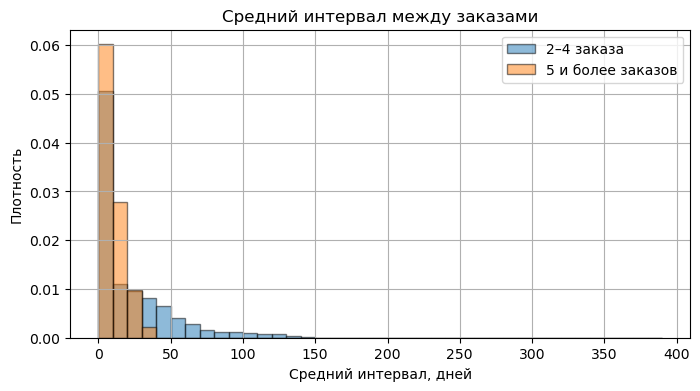

In [109]:
bins = range(0, 400, 10)

plt.figure(figsize=(8, 4))
group_2_4.plot(kind='hist', bins=bins, alpha=0.5, density=True,
               label='2–4 заказа', edgecolor='black')
group_5plus.plot(kind='hist', bins=bins, alpha=0.5, density=True,
                 label='5 и более заказов', edgecolor='black')

plt.title('Средний интервал между заказами')
plt.xlabel('Средний интервал, дней')
plt.ylabel('Плотность')
plt.legend()
plt.grid()
plt.show()

**Вывод:** Различия по среднему интервалу между заказами между двумя группами выражены отчётливо. В группе «2–4 заказа» (7107 пользователей) средний интервал составляет 21.4 дня, медиана — 9.0 дней. В группе «5 и более заказов» (6325 пользователей) 9.6 дня по среднему и 7.8 дня по медиане. 

Таким образом, по среднему интервал у группы «5 и более заказов» короче в 2.2 раза. По медиане разница меньше. У обеих групп среднее выше медианы, причём у группы «2–4 заказа» разрыв очень большой (21.4 и 9.0), а у группы «5 и более заказов» меньше (9.6 против 7.8). 

Можно предположить, что короткий средний интервал между заказами связан с более высокой вероятностью повторных покупок. Пользователи, совершившие 5 и более заказов, возвращаются в среднем почти вдвое быстрее, и их типичная пауза между покупками тоже короче.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [112]:
# Числовые столбцы — их надо указать в interval_cols
num_cols = ['orders_count', 'mean_revenue', 'mean_tickets', 'mean_days_between']

# Считаем матрицу
corr = user_profile[['orders_count', 'mean_revenue', 'mean_tickets', 'mean_days_between',
    'first_device', 'first_event_type', 'first_region', 'first_service']].phik_matrix(interval_cols=num_cols)

# Смотрим, что связано с числом заказов
print(corr[['orders_count']].sort_values('orders_count', ascending=False).round(3))

                   orders_count
orders_count              1.000
first_region              0.128
first_service             0.112
mean_revenue              0.023
mean_tickets              0.000
mean_days_between         0.000
first_device              0.000
first_event_type          0.000


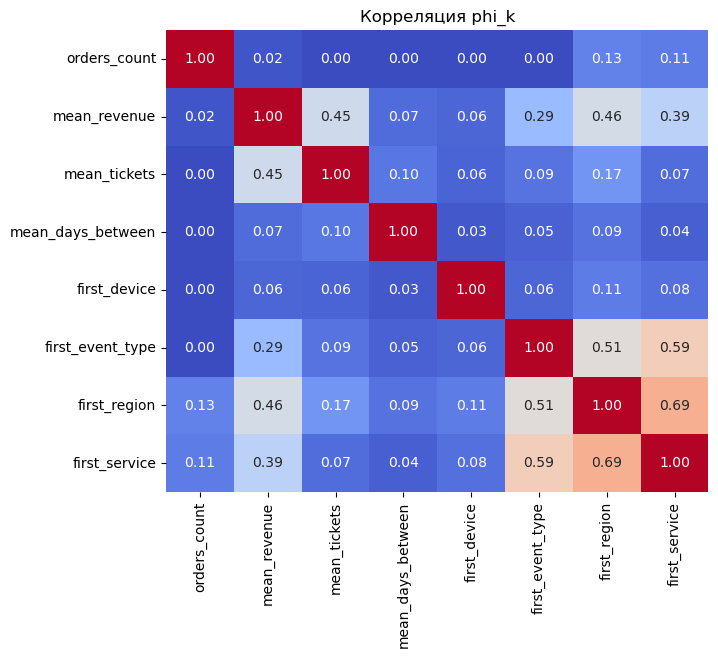

In [113]:
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.title('Корреляция phi_k')
plt.show()

In [114]:
user_profile['orders_count'].value_counts().head(10)

orders_count
1     8319
2     3572
3     2151
4     1384
5      962
6      720
7      534
8      448
9      390
10     292
Name: count, dtype: int64

In [115]:
user_profile['orders_count'].describe()

count    21751.000000
mean        13.209646
std        122.044008
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10194.000000
Name: orders_count, dtype: float64

<Axes: >

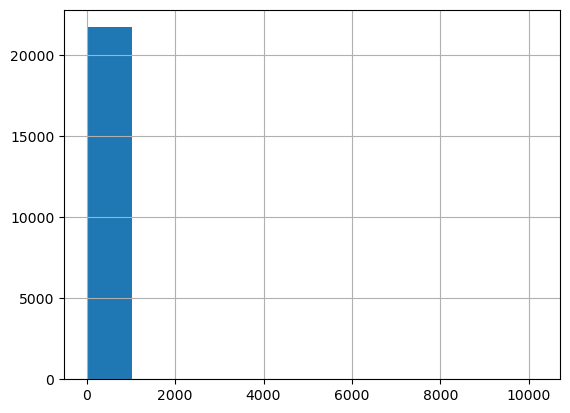

In [116]:
user_profile['orders_count'].hist()

In [117]:
# Сегменты по числу заказов
def seg(x):
    if x == 1:
        return '1 заказ'
    elif x <= 4:
        return '2–4 заказа'
    else:
        return '5 и более заказов'

user_profile['order_segment'] = user_profile['orders_count'].apply(seg)

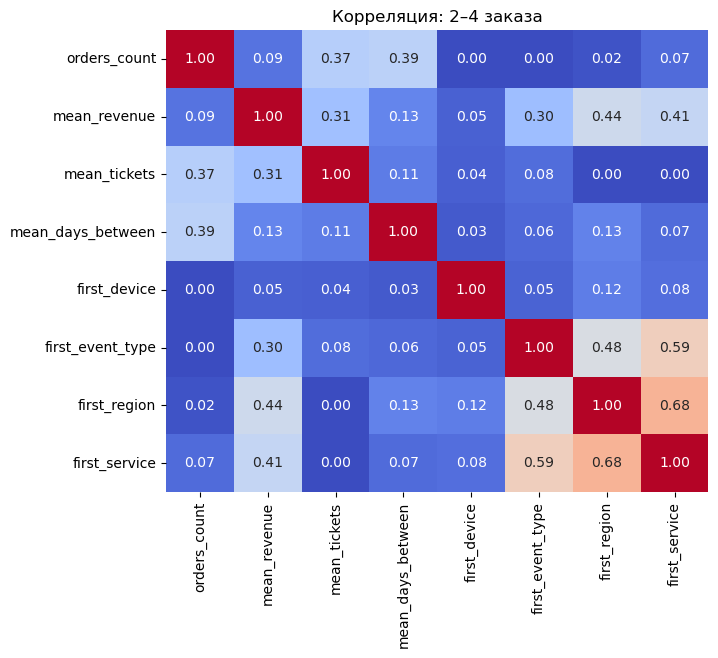

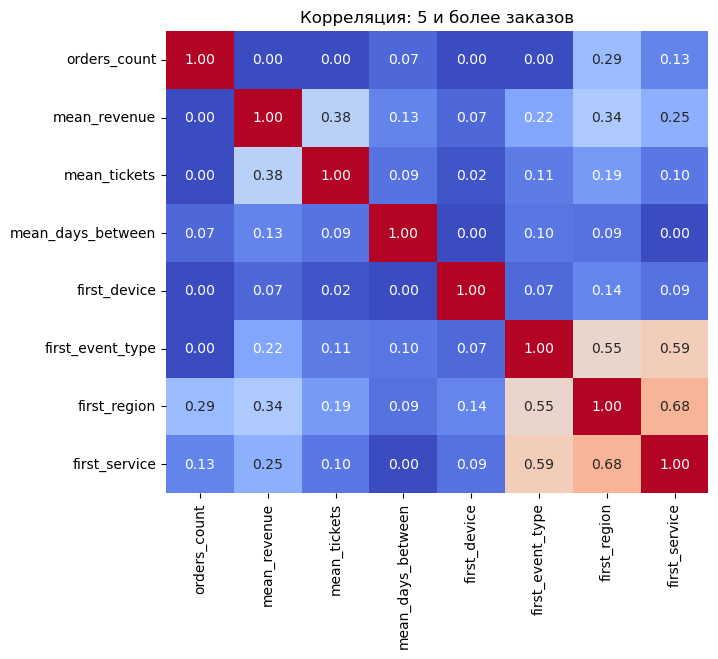

In [118]:
cols = ['orders_count', 'mean_revenue', 'mean_tickets', 'mean_days_between',
        'first_device', 'first_event_type', 'first_region', 'first_service']

for s in ['2–4 заказа', '5 и более заказов']:
    sub = user_profile[user_profile['order_segment'] == s]
    corr_seg = sub[cols].phik_matrix(interval_cols=num_cols)

    plt.figure(figsize=(7, 6))
    sns.heatmap(corr_seg, annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
    plt.title(f'Корреляция: {s}')
    plt.show()

**Вывод:** Общая корреляционная матрица phi_k показывает, что связь признаков профиля с числом заказов крайне слабая, наибольшие значения у факторов first_region (0.128) и first_service (0.112). Низкие значения объясняются сильным перекосом распределения orders_count.

В разрезе групп мы увидели, что при 2-4 заказах средняя отрицательная связь была с факторами mean_tickets и mean_days_between, то есть в этом сегменте рост числа заказов сопровождается снижением среднего числа билетов и сокращением интервала между покупками. В разрезе 5 и болнн средняя отрицательная связь была с факторами first region и first service, то есть связано с географией и билетным оператором первого заказа. Остальные факторы имели более низкую линейную связь.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

В ходе работы были использованы данные по заказам Яндекс Афиши объёмом 290 611 строк и 18 столбцов. Выручка была пересчитана из тенге в рубли, пропуски обнаружены только в `days_since_prev`. Поскольку они появились их наличие объясняется логичными причинами (пользователи с одной покупкой), они были сохранены. Типы данных оптимизированы: `days_since_prev` переведён в `Int64`, `tickets_count` в компактный целочисленный тип, категориальные признаки в `category`. Были удалены отрицательные значения выручки и выбросы `revenue_rub` по 99-му перцентилю, в результате исходная база сокращена на 3288 наблюдений (1.13%), дубликатов не обнаружено.

В итоговой выборке 21 751 пользователь, средняя выручка с заказа составила 103.29 руб., доля с 2 и более заказами 61.75%, с 5 и более 29.08%. Распределения числа заказов и билетов имели выраженные выбросы, поэтому была проведена фильтрация по 95-му перцентилю, что привело к уделению 9.52% данных. Среди точек входа типичного пользователя отмечены концерт (43.5% пользователей), мобильное устройство (82.9% пользователей), Каменевский регион (33.2% пользователей) или Североярская область (17.6% пользователей). Средняя доля вернувшихся по выборке составила 61.8%. Лучше всего удерживают такие точки, как театр (64.1%), выставки (64.3%), desktop (64%), Светополянский округ (66.9%), Широковская область (65.1%) и операторы «Край билетов» (65.7%) и «Дом культуры» (65.3%).

Пользователи, которые начинали со спорта (56.5%), возвращались реже, чем начавшие с концертов (62.1%). В активных регионах доля возврата составила 59.5%, что выше, чем в менее активных(52.7%). Средняя выручка с билета у одноразовых и вернувшихся почти одинакова (41.61 и 40.89 руб.), но медианы различаются заметнее (31.37 и 37.21 руб.). Cегмент «2–3 билета» показывает аномально высокую долю возврата (74.9%), а «5 b и более билетов» низкую (33.2%). День недели первой покупки не оказывает влияния (доли колеблются в диапазоне 60.0–64.1%), но интервал между заказами предположительно может влиять. Например, у группы с 5 и более заказами он 9.6 дня, у 2–4 заказов 21.4 дня. Следовательно, активные клиенты возвращаются почти вдвое быстрее. Корреляционный анализ показал слабые связи факторов с кол-вом заказов на всей выборке. В разрезе сегментов оказалось, что при 2–4 заказах рост числа заказов сопровождается снижением среднего числа билетов и сокращением интервала между покупками. При 5 и более заказах обнаружена отрицательная средняя связь с географией и билетным оператором первого заказа.

Рекомендуется в первую очередь работать с выявленными точками входа (концерты, мобильный трафик, Каменевский и Североярский регионы), развивать успешные сегменты (театр, выставки, desktop, Светополянский и Широковский регионы, операторы «Край билетов» и «Дом культуры»), стимулировать вторую покупку в первые 1–2 недели, так как быстрый возврат связан с будущей лояльностью. Кроме того, сегмент с 1–2 билетами показывает самую низкую долю возврата, хотя является по размеру наибольшим. Ренкомендуется выяснить, что мешает этим клиентам вернуться, усилить рекомендации, предложить скидки на следующий заказ. Также оказалось, что таки точки как спорт и ёлки удерживают покупателей хуже среднего, рекомендуется дополнительно проанализировать их и выяснить как можно развить.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**